In [1]:
# Импорт пакетов
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

In [2]:
#Загрузка данных
employeeRaw = (pd
                .read_excel("Employee.xlsx")
                .rename(columns={'dateMonth':'Date', 'qnt': 'EmpQnt'})
                .sort_values('Date')
                .assign(EmpDelta = lambda x: x["EmpQnt"] - x["EmpQnt"].shift(1))
                .fillna(0)
)

dataRaw = (pd
           .read_excel("indata.xlsx")
           .sort_values('Date')
           .rename(columns={'category':'Category'})
)

print(employeeRaw.tail(5))
print(dataRaw.tail(2))

print(employeeRaw[pd.to_datetime(employeeRaw["Date"]).dt.year == 2023])

          Date  EmpQnt  accepted  fired  EmpDelta
265 2026-03-01    1020        33     39      11.0
266 2026-04-01    1008        27     13     -12.0
267 2026-05-01    1001         6     12      -7.0
268 2026-06-01    1008        19     14       7.0
269 2026-07-01    1007        13     11      -1.0
           Date                                               Name  \
4726 2026-08-01  Принтер ШК TSC ШК TSC TE200 (DT, 203 dpi, 152....   
4727 2026-08-01  Тонер Hi-Black для Kyocera KM-1620/2020/TASKal...   

           Category  Qty  SumWONDS  
4726        Принтер    1  12847.54  
4727  Тонер/Чернила    7   7355.74  
          Date  EmpQnt  accepted  fired  EmpDelta
227 2023-01-01     779        17      8       7.0
228 2023-02-01     788        17     10       9.0
229 2023-03-01     797        19     26       9.0
230 2023-04-01     802        31     16       5.0
231 2023-05-01     813        27     20      11.0
232 2023-06-01     821        28     24       8.0
233 2023-07-01     830      

In [17]:
# Подготовка данных
employeeByYear = (
    employeeRaw
    .assign(Year = lambda x: x['Date'].dt.year)
    .groupby(['Year'])
    .agg(
        EmpQntYear = ('EmpQnt', 'mean')
    )
    .assign(EmpDeltaYear = lambda x: x['EmpQntYear'] - x['EmpQntYear'].shift(1))
    .fillna(0)
)

print(employeeByYear.head())

      EmpQntYear  EmpDeltaYear
Year                          
2004  646.000000      0.000000
2005  646.333333      0.333333
2006  647.583333      1.250000
2007  649.000000      1.416667
2008  650.500000      1.500000


In [4]:

data = (
    employeeRaw
    .merge(dataRaw, how='inner', on='Date')
    .assign(Year = lambda x: x['Date'].dt.year)
    .assign(YearMonth = lambda x: x['Date'].dt.strftime('%Y%m'))
    .assign(SumTR = lambda x: x['SumWONDS'] / 1000)
    .merge(employeeByYear, how='inner', on='Year')
)
print(data)


           Date  EmpQnt  accepted  fired  EmpDelta  \
0    2016-07-01     837        14     26      -1.0   
1    2016-07-01     837        14     26      -1.0   
2    2016-07-01     837        14     26      -1.0   
3    2016-07-01     837        14     26      -1.0   
4    2016-07-01     837        14     26      -1.0   
...         ...     ...       ...    ...       ...   
4721 2026-07-01    1007        13     11      -1.0   
4722 2026-07-01    1007        13     11      -1.0   
4723 2026-07-01    1007        13     11      -1.0   
4724 2026-07-01    1007        13     11      -1.0   
4725 2026-07-01    1007        13     11      -1.0   

                                                   Name  \
0                               Журнал "1С:Предприятия"   
1                      Журнал "Системный администратор"   
2                                    Фильтр сетевой 5 м   
3     Накопитель HDD 2Tb SATA-III Seagate surveillan...   
4     Картридж CANON PFI-107 для iPF 670/680/685/770... 

In [5]:

dataTotalByMonth = (
    data
    .groupby(['YearMonth'])
    .agg({'EmpQnt':'min', 'EmpDelta': 'min', 'SumTR': 'sum'})
    .assign(SumByPerson = lambda x: x['SumTR'] / x['EmpQnt'])
    .assign(SumDelta = lambda x: x['SumTR'] - x['SumTR'].shift(1))
    .assign(SumDeltaByPerson = lambda x: x['SumDelta'] / x['EmpDelta'])
    .fillna(0)
    .replace([np.inf, -np.inf], 0)
)

print(dataTotalByMonth.tail(5))

           EmpQnt  EmpDelta       SumTR  SumByPerson   SumDelta  \
YearMonth                                                         
202603       1020      11.0   979.76483     0.960554  451.21607   
202604       1008     -12.0   316.99592     0.314480 -662.76891   
202605       1001      -7.0  1018.57682     1.017559  701.58090   
202606       1008       7.0   679.08198     0.673692 -339.49484   
202607       1007      -1.0   675.30673     0.670612   -3.77525   

           SumDeltaByPerson  
YearMonth                    
202603            41.019643  
202604            55.230742  
202605          -100.225843  
202606           -48.499263  
202607             3.775250  


In [6]:

dataTotalByYear = (
    data
    .groupby(['Year'])
    .agg(
        SumTR = ('SumTR', 'sum'),
        EmpQntYear = ('EmpQntYear', 'min'),
        EmpDeltaYear = ('EmpDeltaYear', 'min')
    )
    .assign(SumByPerson = lambda x: x['SumTR'] / x['EmpQntYear'])
    .assign(SumDelta = lambda x: x['SumTR'] - x['SumTR'].shift(1))
    .assign(SumDeltaByPerson = lambda x: x['SumDelta'] / x['EmpDeltaYear'])
    .fillna(0)
    .replace([np.inf, -np.inf], 0)
)

print(dataTotalByYear)

            SumTR   EmpQntYear  EmpDeltaYear  SumByPerson     SumDelta  \
Year                                                                     
2016   4148.94134   845.000000     17.916667     4.909990      0.00000   
2017   3729.73652   839.750000     -5.250000     4.441484   -419.20482   
2018   3992.15732   896.333333     56.583333     4.453876    262.42080   
2019   5997.34836   927.250000     30.916667     6.467887   2005.19104   
2020   8515.87995   931.166667      3.916667     9.145387   2518.53159   
2021   6926.32731   843.916667    -87.250000     8.207359  -1589.55264   
2022   9544.11489   780.583333    -63.333333    12.226901   2617.78758   
2023  38499.58820   854.750000     74.166667    45.041928  28955.47331   
2024  10701.64170  1039.000000    184.250000    10.299944 -27797.94650   
2025   7745.38194  1027.750000    -11.250000     7.536251  -2956.25976   
2026   4198.27504  1008.285714    -19.464286     4.163775  -3547.10690   

      SumDeltaByPerson  
Year        

In [7]:
dataTotalByCategory = (
    data
    .groupby(['Category'])
    .agg({'Qty': 'sum', 'SumTR': 'sum'})
    .reset_index()
)


print(dataTotalByCategory.head(4))

       Category  Qty      SumTR
0     Батарейка  236   84.24121
1  Блок питания  224  647.56981
2    Веб-камера   46  229.49885
3    Видеокарта   99  801.43660


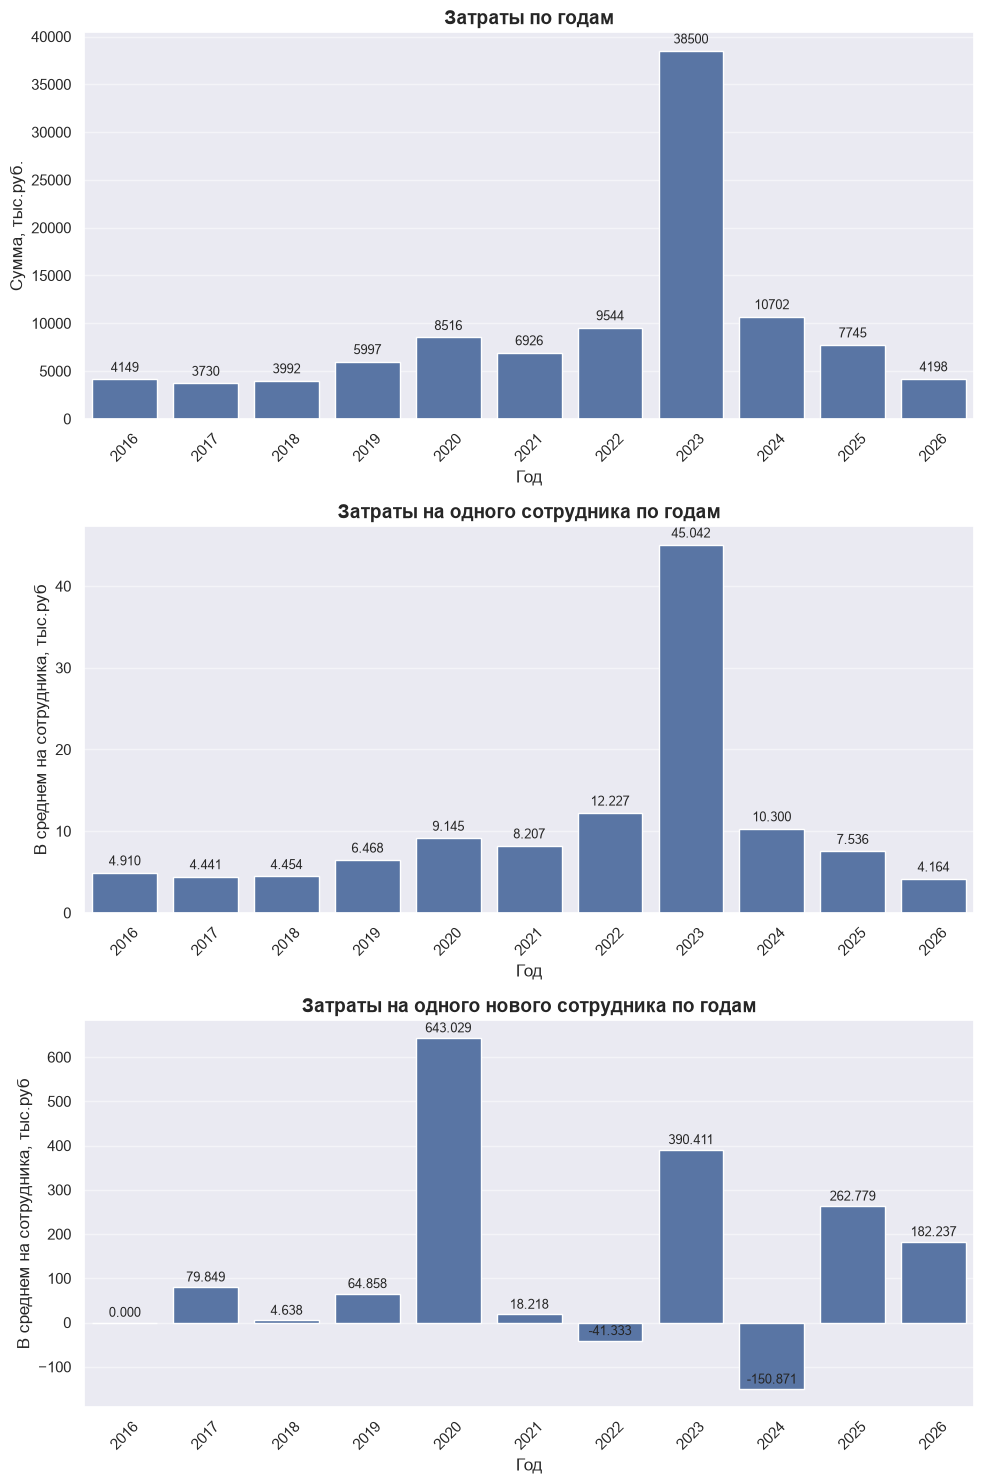

In [8]:
# Настройка стиля
plt.figure(figsize=(10, 15))

# Левый график - Sum по годам
plt.subplot(3, 1, 1)
sns.barplot(x=dataTotalByYear.index, y='SumTR', data=dataTotalByYear)
plt.title('Затраты по годам', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Сумма, тыс.руб.')
plt.xticks(rotation=45)

# Добавление значений на столбцы
for i, v in enumerate(dataTotalByYear['SumTR']):
    plt.text(i, v + max(dataTotalByYear['SumTR']) * 0.02, f'{v:.0f}',
             ha='center', fontsize=9)

# Правый график - SumByPerson по годам
plt.subplot(3, 1, 2)
sns.barplot(x=dataTotalByYear.index, y='SumByPerson', data=dataTotalByYear)
plt.title('Затраты на одного сотрудника по годам', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('В среднем на сотрудника, тыс.руб')
plt.xticks(rotation=45)

# Добавление значений на столбцы
for i, v in enumerate(dataTotalByYear['SumByPerson']):
    plt.text(i, v + max(dataTotalByYear['SumByPerson']) * 0.02, f'{v:.3f}',
             ha='center', fontsize=9)

plt.subplot(3, 1, 3)
sns.barplot(x=dataTotalByYear.index, y='SumDeltaByPerson', data=dataTotalByYear)
plt.title('Затраты на одного нового сотрудника по годам', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('В среднем на сотрудника, тыс.руб')
plt.xticks(rotation=45)

# Добавление значений на столбцы
for i, v in enumerate(dataTotalByYear['SumDeltaByPerson']):
    plt.text(i, v + max(dataTotalByYear['SumDeltaByPerson']) * 0.02, f'{v:.3f}',
             ha='center', fontsize=9)

# Настройка общего расположения
plt.tight_layout()
plt.show()

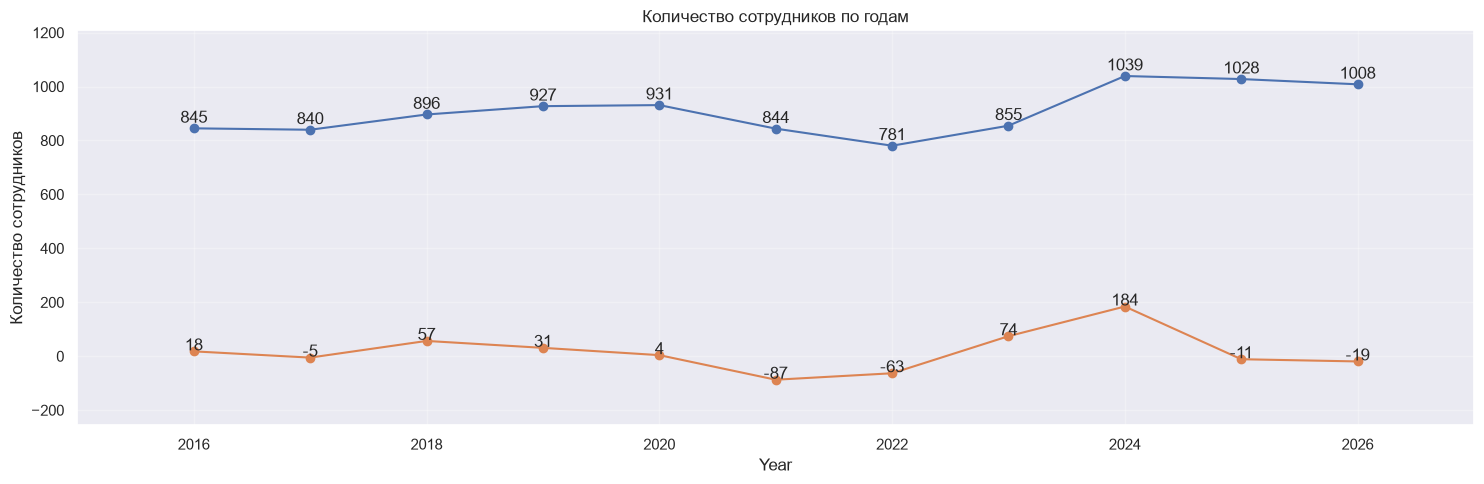

In [9]:
# Построение графика EmpQnt
# Самый простой способ - использовать plot() от pandas
dataTotalByYear['EmpQntYear'].plot(kind='line', marker='o', figsize=(15, 5),
                                title='Количество сотрудников по годам')
plt.ylabel('Количество сотрудников')
plt.xlabel('Год')
plt.grid(True, alpha=0.3)
# Устанавливаем отступы по оси X вручную
x_min = dataTotalByYear.index.min() - 1
x_max = dataTotalByYear.index.max() + 1
plt.xlim(x_min, x_max)
# Добавляем отступы сверху и снизу
plt.margins(y=0.15)  # 15% отступ сверху и снизу
for x, y in zip(dataTotalByYear.index, dataTotalByYear['EmpQntYear']):
    plt.text(x, y + max(dataTotalByYear['EmpQntYear']) * 0.02, f'{y:.0f}', ha='center', fontsize=12)

dataTotalByYear['EmpDeltaYear'].plot(kind='line', marker='o', figsize=(15, 5),
                                title='Количество сотрудников по годам')
for x, y in zip(dataTotalByYear.index, dataTotalByYear['EmpDeltaYear']):
    plt.text(x, y + max(dataTotalByYear['EmpDeltaYear']) * 0.02, f'{y:.0f}', ha='center', fontsize=12)

# Показать график
plt.tight_layout()
plt.show()

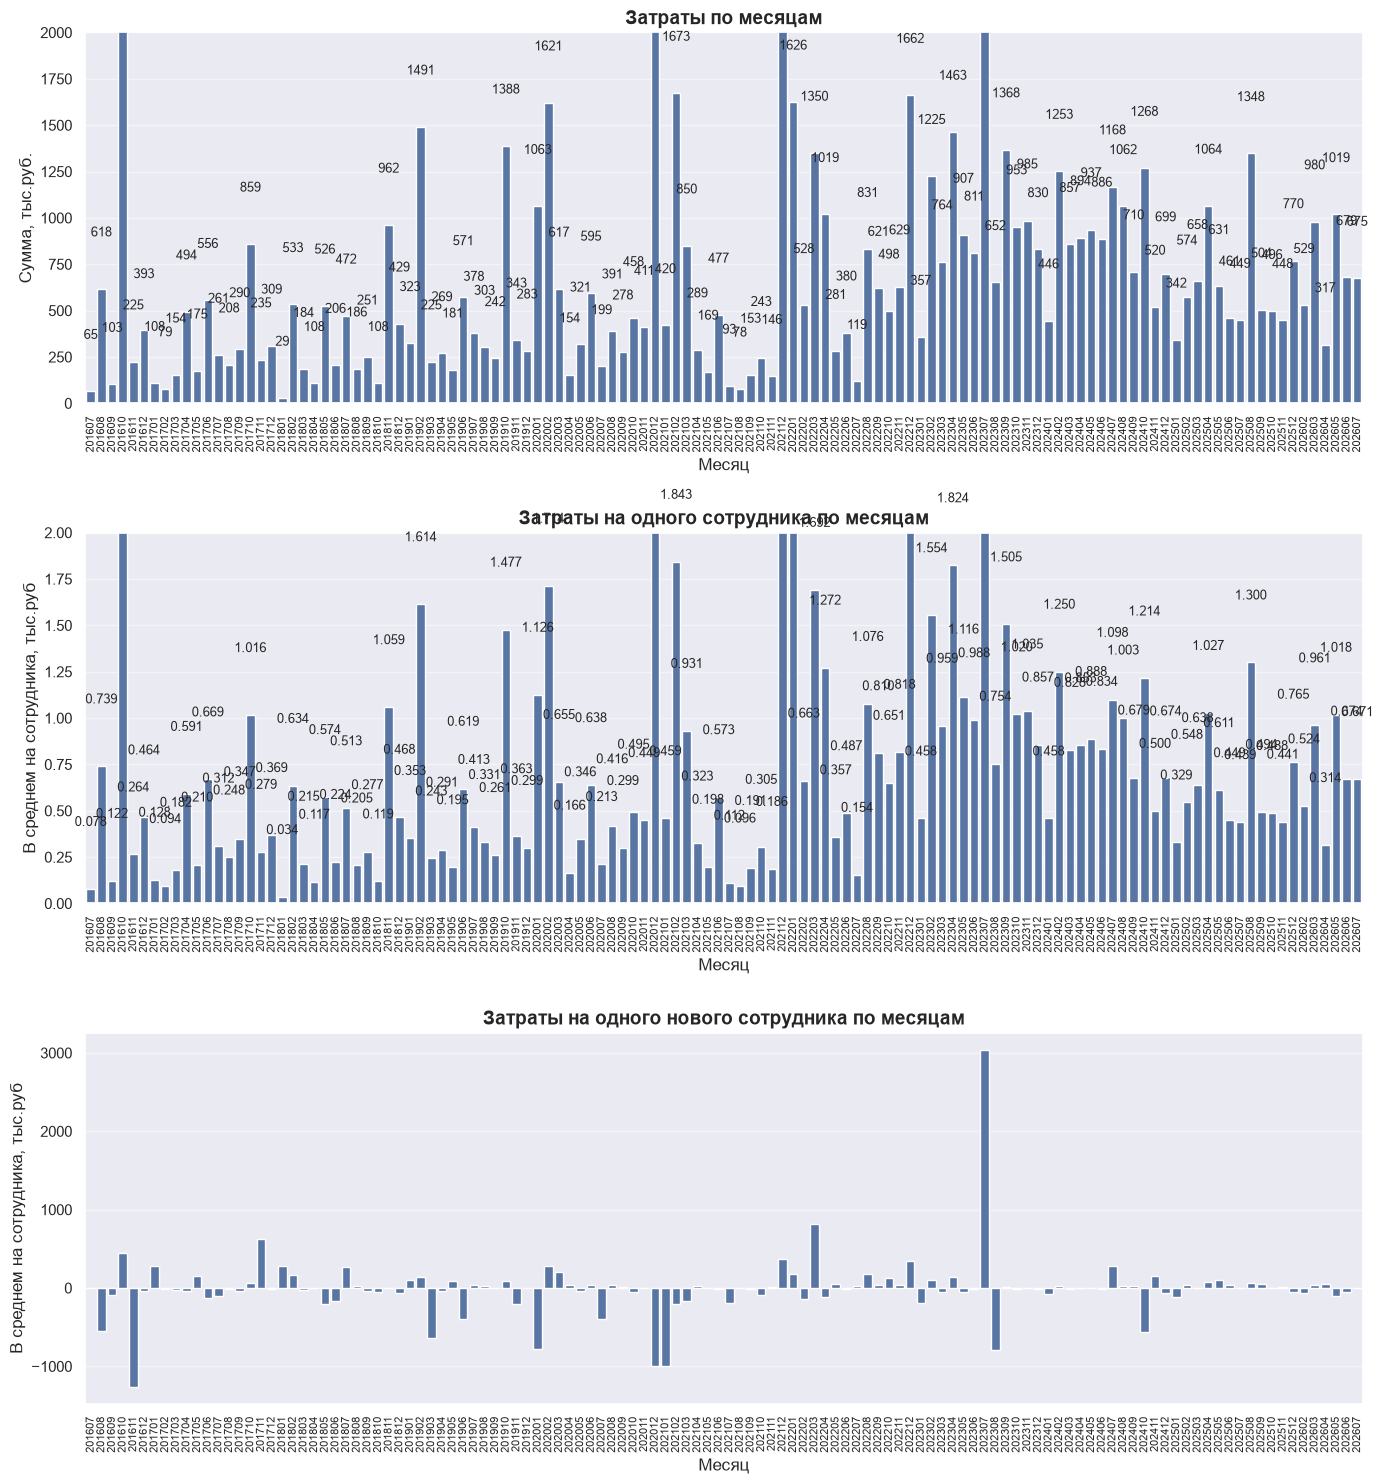

In [10]:
# Настройка стиля
plt.figure(figsize=(14, 15))

# Левый график - Sum по годам
plt.subplot(3, 1, 1)
sns.barplot(x=dataTotalByMonth.index, y='SumTR', data=dataTotalByMonth)
plt.title('Затраты по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Сумма, тыс.руб.')
plt.xticks(rotation=90, fontsize=8)
plt.ylim(0, 2000)

# Добавление значений на столбцы
for i, v in enumerate(dataTotalByMonth['SumTR']):
    if v < 2000:
        plt.text(i, v + max(dataTotalByMonth['SumTR']) * 0.01, f'{v:.0f}',
             ha='center', fontsize=9)
# Правый график - SumByPerson по годам
plt.subplot(3, 1, 2)
sns.barplot(x=dataTotalByMonth.index, y='SumByPerson', data=dataTotalByMonth)
plt.title('Затраты на одного сотрудника по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('В среднем на сотрудника, тыс.руб')
plt.xticks(rotation=90, fontsize=8)

# Добавление значений на столбцы
for i, v in enumerate(dataTotalByMonth['SumByPerson']):
    if v < 2:
        plt.text(i, v + max(dataTotalByMonth['SumByPerson']) * 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.ylim(0, 2)

# Правый график - SumByPerson по годам
plt.subplot(3, 1, 3)
sns.barplot(x=dataTotalByMonth.index, y='SumDeltaByPerson', data=dataTotalByMonth)
plt.title('Затраты на одного нового сотрудника по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('В среднем на сотрудника, тыс.руб')
plt.xticks(rotation=90, fontsize=8)

# Настройка общего расположения
plt.tight_layout()
plt.show()

In [11]:
dataByMonth = (
    data
    .groupby(['YearMonth', 'Category'])
    .agg({'EmpQnt':'min', 'EmpDelta': 'min', 'SumTR': 'sum', 'Qty': 'sum'})
    .sort_values(['YearMonth', 'Category'])
    .assign(SumDelta = lambda x: x['SumTR'] - x['SumTR'].shift(1))
    .assign(SumDeltaByPerson = lambda x: x['SumDelta'] / x['EmpDelta'])
    .reset_index()
    .fillna(0)
    .replace([np.inf, -np.inf], 0)
)

print(dataByMonth)

     YearMonth                 Category  EmpQnt  EmpDelta     SumTR  Qty  \
0       201607             Жесткий диск     837      -1.0  12.79662    2   
1       201607                 Картридж     837      -1.0   8.22034    2   
2       201607               Клавиатура     837      -1.0   1.35595    5   
3       201607  Коммутатор/Свитч/Роутер     837      -1.0  13.47458    1   
4       201607                     Мышь     837      -1.0   0.97460    5   
...        ...                      ...     ...       ...       ...  ...   
1461    202607                      ОЗУ    1007      -1.0  46.34837    6   
1462    202607                Процессор    1007      -1.0  19.99918    1   
1463    202607                   Прочее    1007      -1.0  36.14706   50   
1464    202607     Сетевое оборудование    1007      -1.0  21.31066    1   
1465    202607            Тонер/Чернила    1007      -1.0   9.42620   10   

      SumDelta  SumDeltaByPerson  
0      0.00000           0.00000  
1     -4.57628   

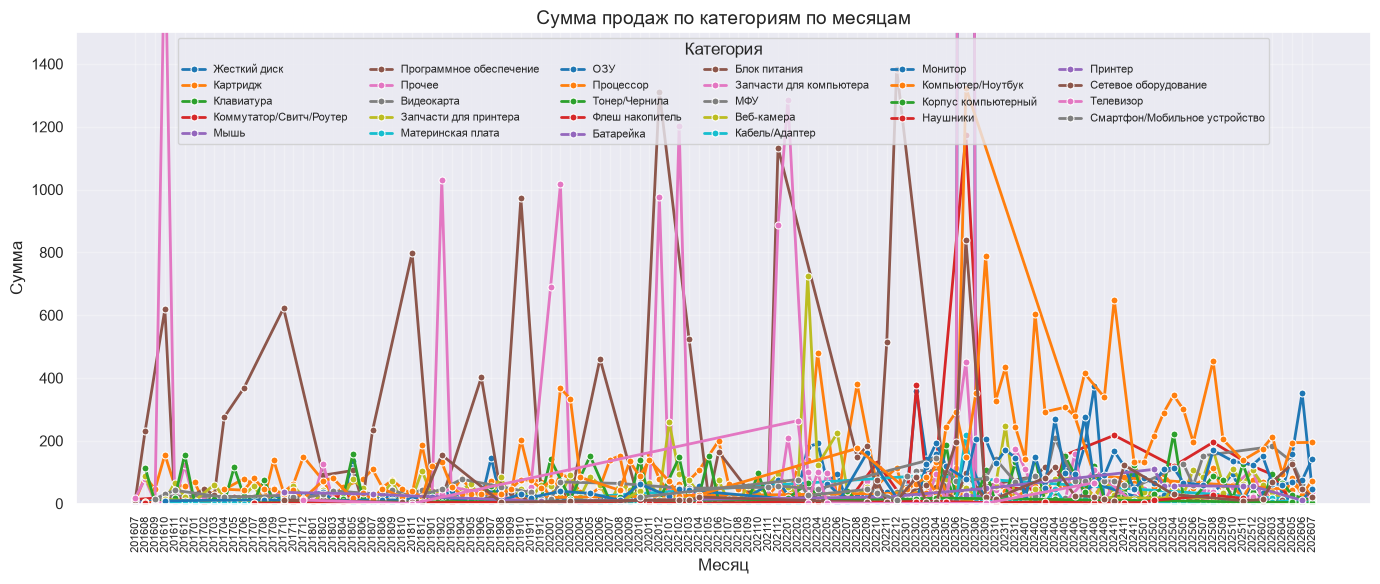

In [12]:

# Построение графика
plt.figure(figsize=(14, 6))

# Линейный график
sns.lineplot(
    data=dataByMonth,
    x='YearMonth',
    y='SumTR',
    hue='Category',
    marker='o',
    linewidth=2,
    markersize=5,
    palette=sns.color_palette("tab10", n_colors=28)
)

# Настройка графика
plt.ylim(bottom=0, top = 1500)
plt.title('Сумма продаж по категориям по месяцам', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Сумма', fontsize=12)
plt.legend(title='Категория', bbox_to_anchor=(0.5, 1), loc='upper center', ncol=6, fontsize=8)
plt.xticks(rotation=90, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

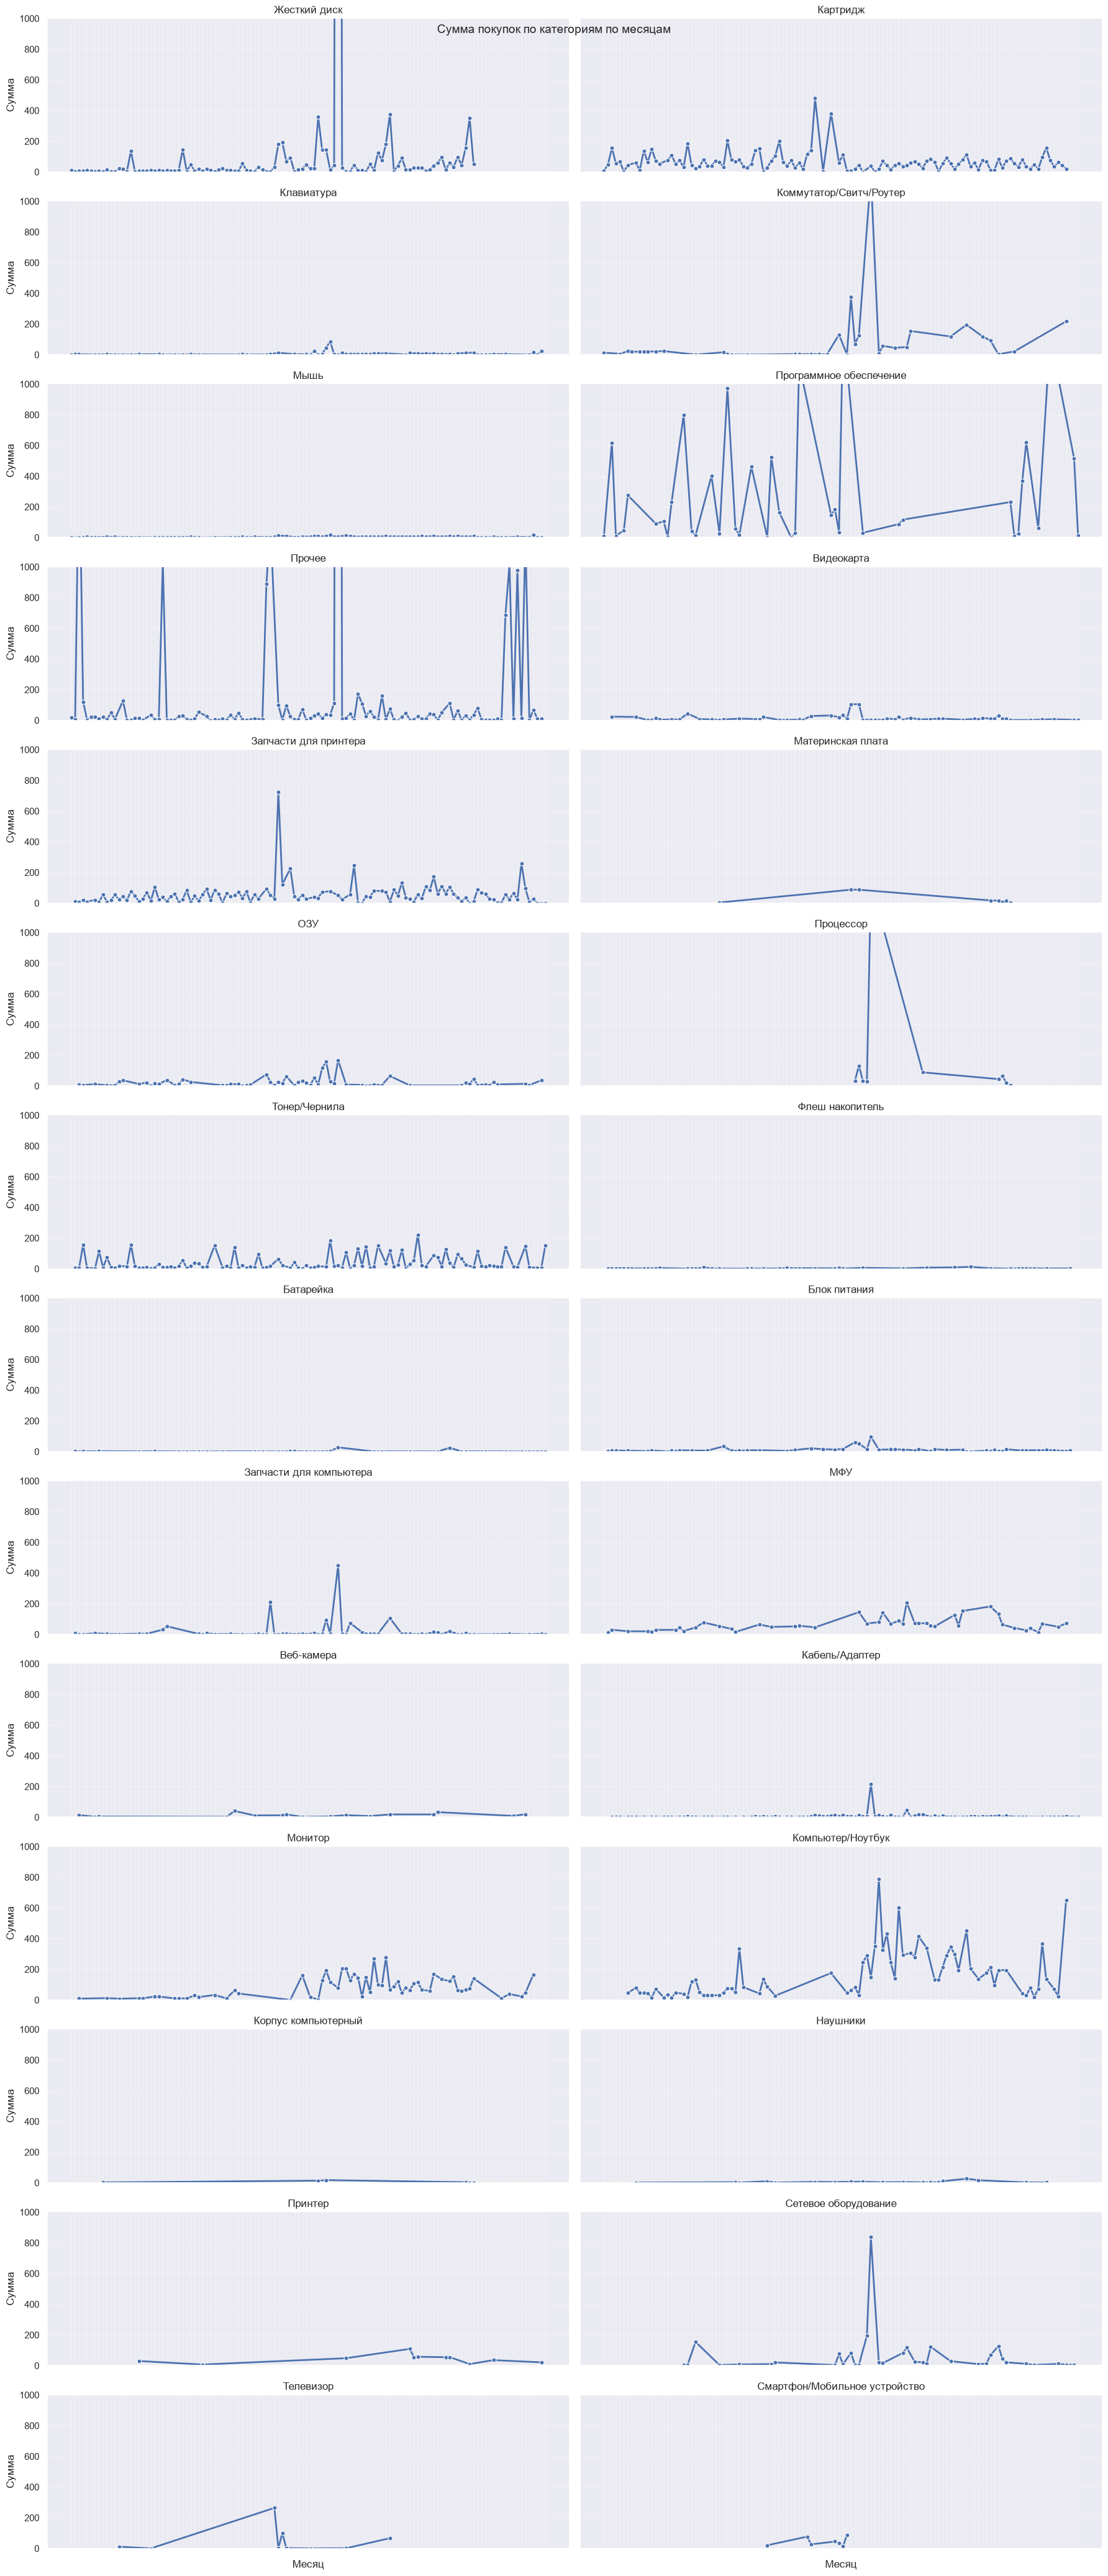

In [13]:
# Создаем сетку графиков по категориям
g = sns.FacetGrid(
    dataByMonth,
    col='Category',  # разбивка по категориям
    col_wrap=2,      # количество колонок (3 колонки, значит будет 2 ряда для 5 графиков)
    height=3,        # высота каждого графика
    aspect=3,      # соотношение сторон (ширина/высота)
    sharey=True,     # общая шкала Y для всех графиков
    sharex=True      # общая шкала X для всех графиков
)

# Добавляем линии на каждый график
g.map(
    sns.lineplot,
    'YearMonth',
    'SumTR',
    marker='o',
    linewidth=2,
    markersize=5
)

# Настройка графиков
g.set_axis_labels('Месяц', 'Сумма')
g.set_xticklabels(rotation=90, fontsize=8)
g.set_titles(col_template='{col_name}')  # заголовок каждого графика - название категории
g.figure.subplots_adjust(top=0.9)           # отступ сверху для общего заголовка

# Общий заголовок
g.figure.suptitle('Сумма покупок по категориям по месяцам', fontsize=14)

# Настройка осей Y
for ax in g.axes.flat:
    ax.set_ylim(bottom=0, top=1000)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

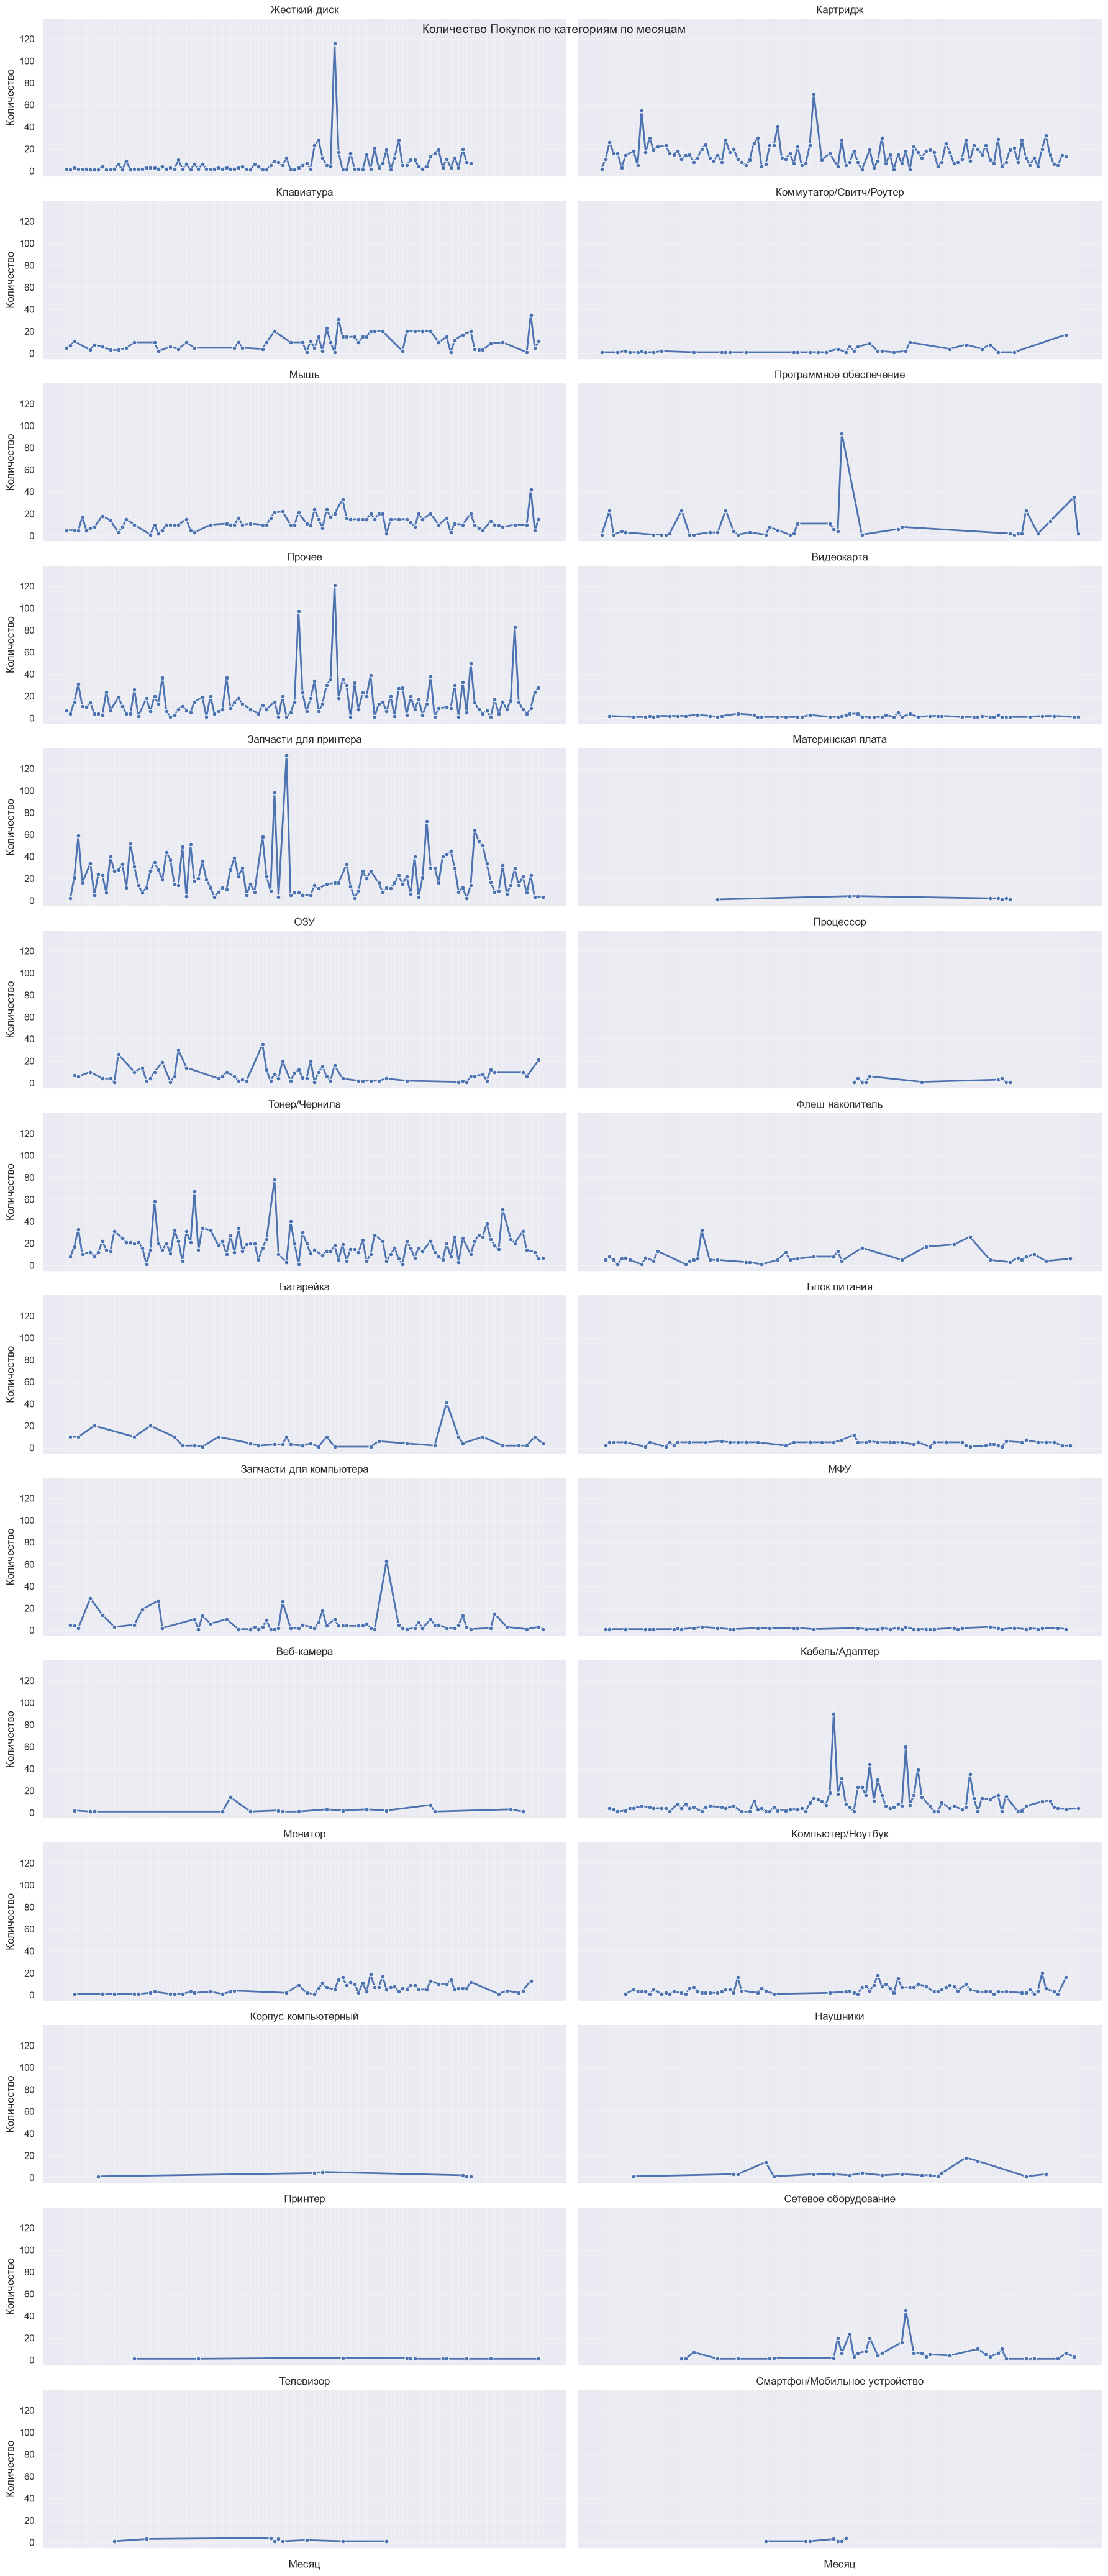

In [14]:
# Создаем сетку графиков по категориям
g = sns.FacetGrid(
    dataByMonth,
    col='Category',  # разбивка по категориям
    col_wrap=2,      # количество колонок (3 колонки, значит будет 2 ряда для 5 графиков)
    height=3,        # высота каждого графика
    aspect=3,      # соотношение сторон (ширина/высота)
    sharey=True,     # общая шкала Y для всех графиков
    sharex=True      # общая шкала X для всех графиков
)

# Добавляем линии на каждый график
g.map(
    sns.lineplot,
    'YearMonth',
    'Qty',
    marker='o',
    linewidth=2,
    markersize=5
)

# Настройка графиков
g.set_axis_labels('Месяц', 'Количество')
g.set_xticklabels(rotation=90, fontsize=8)
g.set_titles(col_template='{col_name}')  # заголовок каждого графика - название категории
g.figure.subplots_adjust(top=0.9)           # отступ сверху для общего заголовка

# Общий заголовок
g.figure.suptitle('Количество Покупок по категориям по месяцам', fontsize=14)

# Настройка осей Y
for ax in g.axes.flat:
    # ax.set_ylim(bottom=0, top=1500000)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

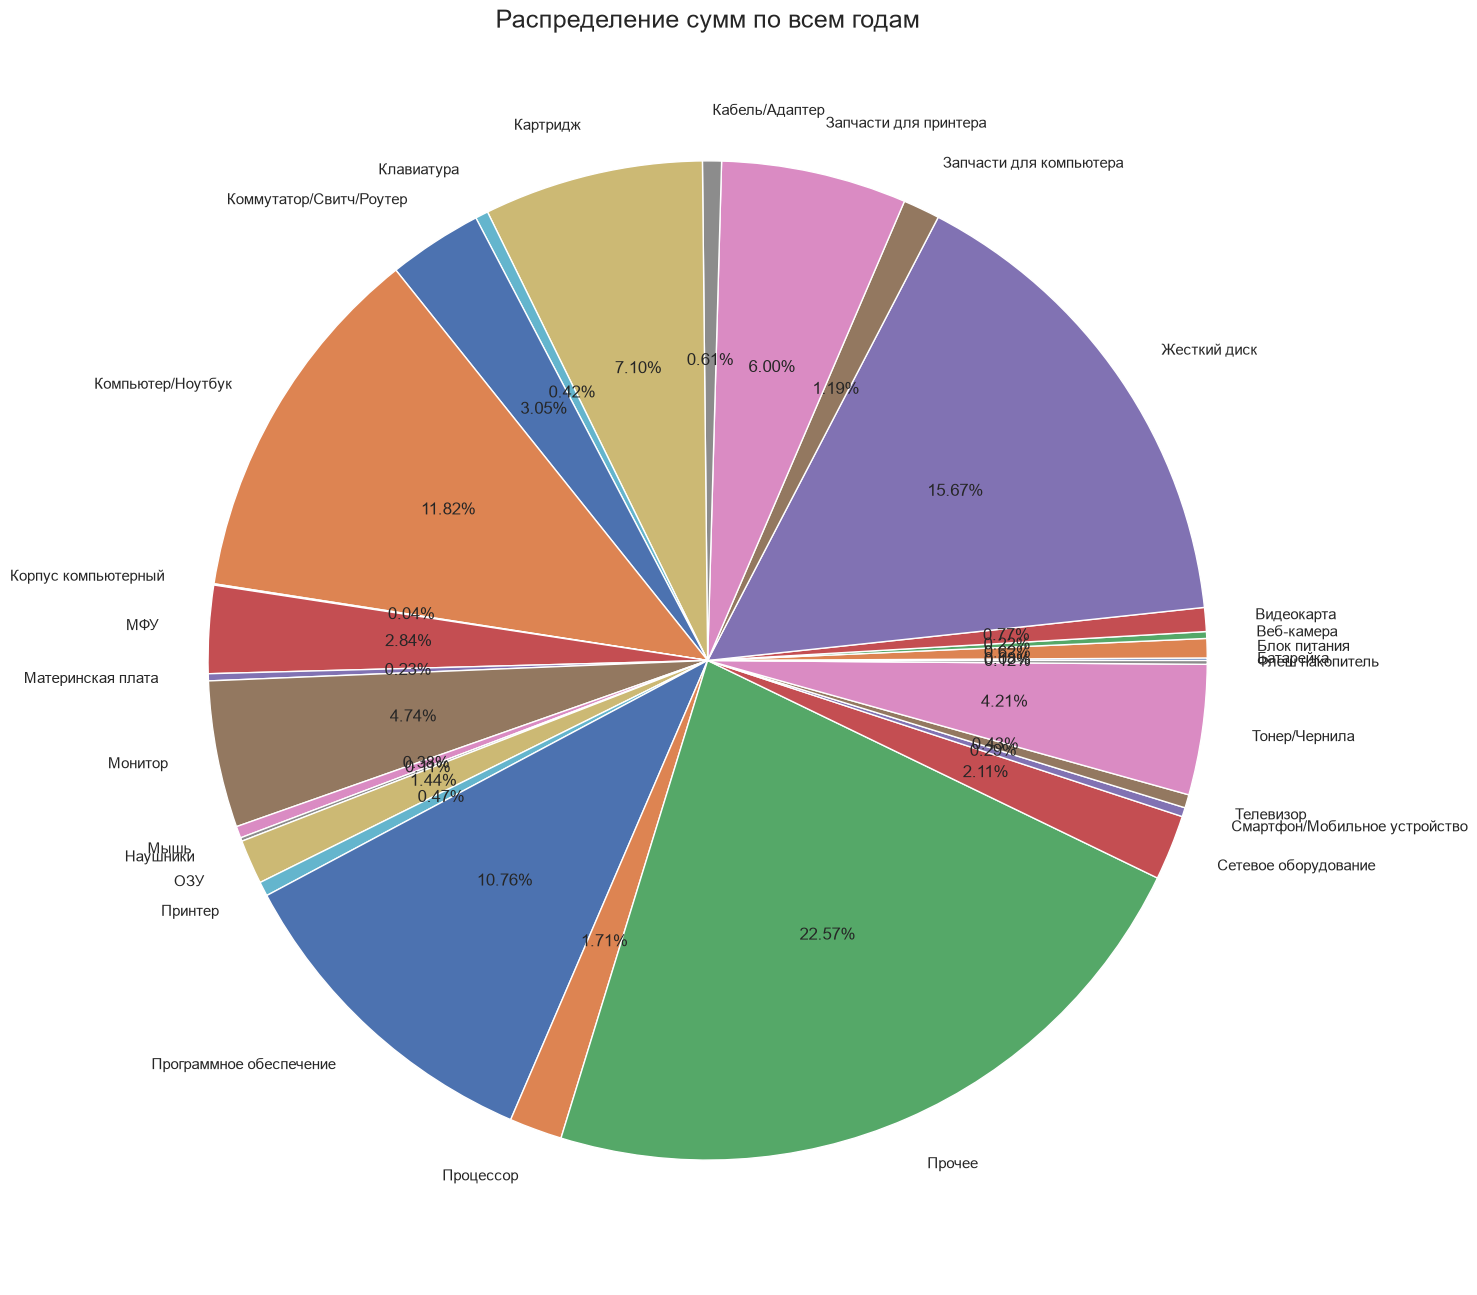

In [15]:
plt.figure(figsize=(15, 15))
plt.pie(x = dataTotalByCategory["SumTR"], labels=dataTotalByCategory["Category"], autopct = "%.2f%%")
plt.title("Распределение сумм по всем годам", fontsize = 18)
plt.tight_layout()
plt.show()

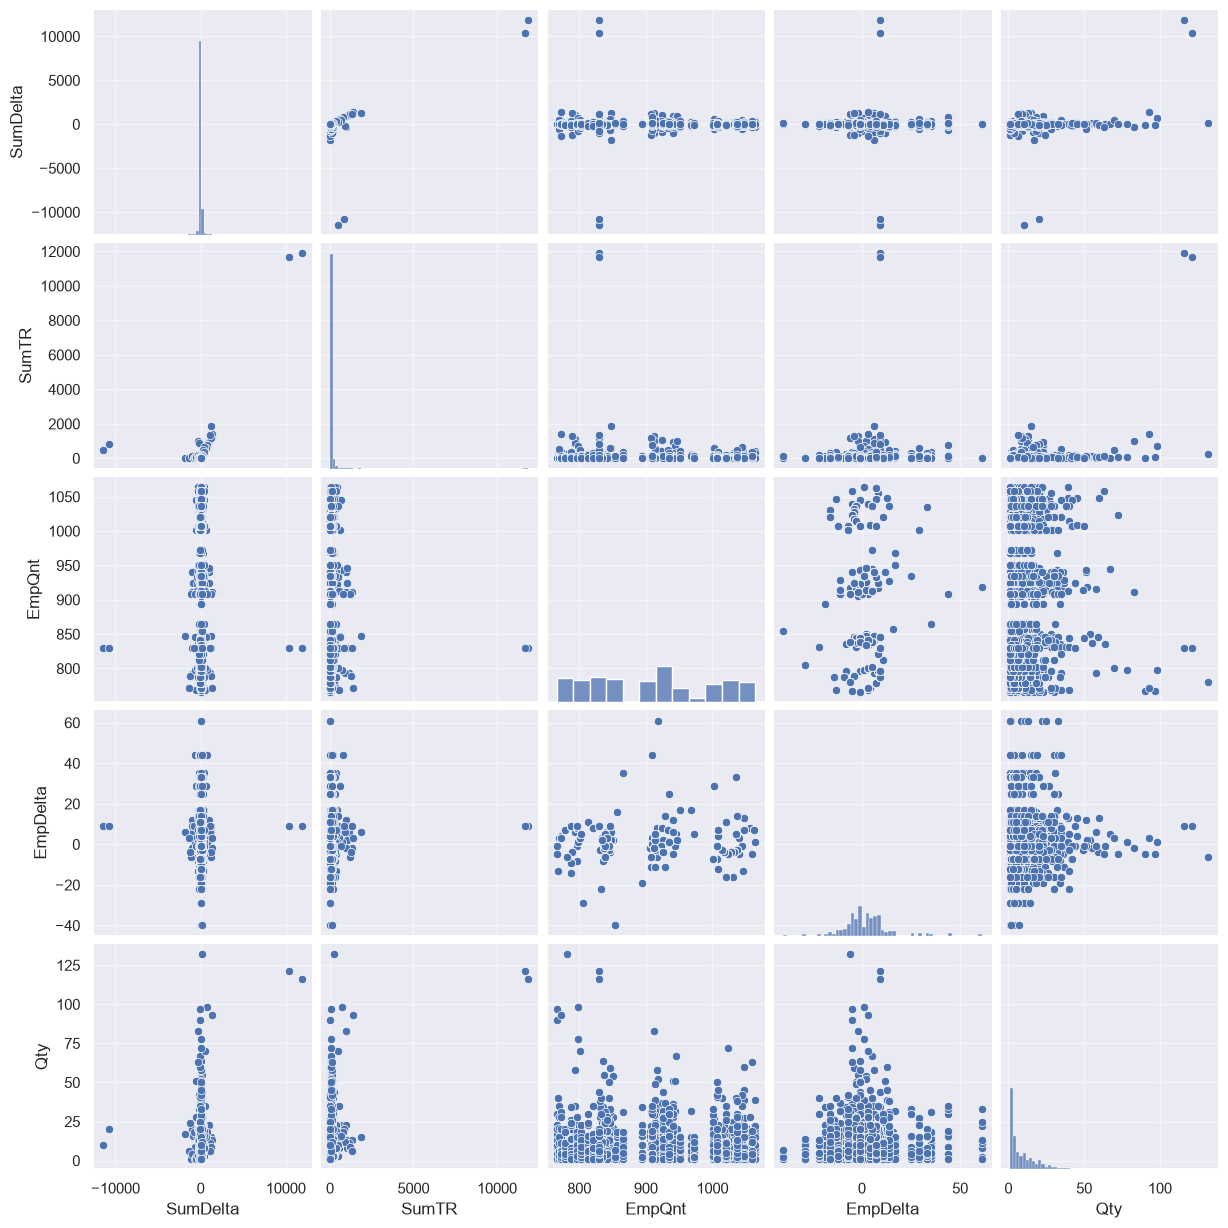

In [65]:
    sns.pairplot(dataByMonth[["SumDelta", "SumTR", "EmpQnt", "EmpDelta", "Qty"]])
    plt.show()